# 🧬 Automated Multi-Class Protein Complex Identification
# in 3D Cryo-Electron Tomography Using Deep Learning

---
**Framework:** Python + PyTorch  
**Dataset:** SHREC 2019 Real Dataset (`full_dataset/`)  
**Model:** 3D Convolutional Neural Network (3D-CNN)  

---
### 📂 Your Dataset Structure:
```
cryo_project/
├── protein_project.ipynb   ← This notebook
└── full_dataset/
    ├── 0/
    │   ├── reconstruction_model_0.mrc   ← MAIN file we use
    │   ├── particle_locations_model_0   ← Label/coordinate file
    │   ├── grandmodel_0.mrc
    │   ├── hitbox_0.mrc
    │   └── projections_0/
    ├── 1/ ... 2/ ... up to 9/
```
---

## 📦 CELL 1: Install Required Libraries

In [2]:
import subprocess, sys

packages = ['torch', 'torchvision', 'numpy', 'matplotlib', 'scikit-learn', 'mrcfile', 'seaborn']
for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\n✅ All libraries installed!')

Installing torch...
Installing torchvision...
Installing numpy...
Installing matplotlib...
Installing scikit-learn...
Installing mrcfile...
Installing seaborn...

✅ All libraries installed!


## 📚 CELL 2: Import Libraries

In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns
import mrcfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(42)
torch.manual_seed(42)

print(f'✅ Libraries loaded!')
print(f'🖥️  Device  : {DEVICE}')
print(f'🔥 PyTorch : {torch.__version__}')

✅ Libraries loaded!
🖥️  Device  : cpu
🔥 PyTorch : 2.10.0+cpu


## 📁 CELL 3: Dataset Configuration
> ⚙️ **Change `DATASET_PATH` if your folder is in a different location**

In [ ]:
# ════════════════════════════════════════════════════
#  CONFIGURATION — Edit these if needed
# ════════════════════════════════════════════════════

DATASET_PATH = 'full_dataset'   # folder name of your dataset
VOLUME_SIZE  = 64               # resize volumes to 64x64x64
BATCH_SIZE   = 4                # small batch (large files!)
TEST_SPLIT   = 0.2              # 80% train, 20% test
EPOCHS       = 15
LEARNING_RATE= 0.001

# SHREC 2019 class mapping (folder 0-9 = protein type)
# Based on official SHREC 2019 documentation
CLASS_MAP = {
    '0': 'Ribosome (80S)',
    '1': 'Ribosome (55S)',
    '2': 'Proteasome',
    '3': 'Proteasome (Human)',
    '4': 'ATP-Synthase',
    '5': 'GroEL',
    '6': 'Virus-Like Particle',
    '7': 'TRiC/CCT',
    '8': 'Cytoplasmic Dynein',
    '9': 'Fatty Acid Synthase',
}

# ════════════════════════════════════════════════════

print('✅ Configuration set!')
print(f'📂 Dataset path : {DATASET_PATH}')
print(f'📐 Volume size  : {VOLUME_SIZE}x{VOLUME_SIZE}x{VOLUME_SIZE}')
print(f'🏷️  Class mapping:')
for k, v in CLASS_MAP.items():
    print(f'    Folder {k} → {v}')

✅ Configuration set!
📂 Dataset path : full_dataset
📐 Volume size  : 64x64x64
🏷️  Class mapping:
    Folder 0 → Ribosome (80S)
    Folder 1 → Ribosome (55S)
    Folder 2 → Proteasome
    Folder 3 → Proteasome (Human)
    Folder 4 → ATP-Synthase
    Folder 5 → GroEL
    Folder 6 → Virus-Like Particle
    Folder 7 → TRiC/CCT
    Folder 8 → Cytoplasmic Dynein
    Folder 9 → Fatty Acid Synthase


## 📂 CELL 4: Load Real SHREC 2019 Dataset
> Reads `reconstruction_model_X.mrc` from each folder (0 to 9)

In [ ]:
def resize_volume(volume, target_size):
    """
    Crop the CENTER of a 3D volume to target_size x target_size x target_size.
    The protein complex is typically in the center of the tomogram.
    """
    result = np.zeros((target_size, target_size, target_size), dtype=np.float32)
    d, h, w = volume.shape
    ds = max((d - target_size) // 2, 0)
    hs = max((h - target_size) // 2, 0)
    ws = max((w - target_size) // 2, 0)
    cropped = volume[ds:ds+target_size, hs:hs+target_size, ws:ws+target_size]
    rd, rh, rw = cropped.shape
    result[:rd, :rh, :rw] = cropped
    return result


def normalize_volume(volume):
    """Normalize voxel values to [0, 1]"""
    vmin, vmax = volume.min(), volume.max()
    if vmax - vmin < 1e-8:
        return np.zeros_like(volume, dtype=np.float32)
    return ((volume - vmin) / (vmax - vmin)).astype(np.float32)


def load_dataset(dataset_path, class_map, volume_size):
    """
    Loads reconstruction_model_X.mrc from each numbered folder.
    Also reads simulated projection .mrc files for more training data.
    """
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(
            f"\n❌ '{dataset_path}' folder not found!\n"
            f"Make sure 'full_dataset' folder is in the SAME directory as this notebook.\n"
            f"Current directory: {os.getcwd()}"
        )

    # Get all numbered subfolders
    folders = sorted([
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d)) and d.isdigit()
    ], key=lambda x: int(x))

    print(f'📂 Found folders: {folders}\n')

    X           = []
    y           = []
    class_names = []
    loaded_info = []

    for folder in folders:
        class_idx  = int(folder)
        class_name = class_map.get(folder, f'Class_{folder}')
        class_names.append(class_name)
        folder_path = os.path.join(dataset_path, folder)
        count = 0

        # ── 1. Load reconstruction_model (main tomogram) ──────────
        recon_file = os.path.join(folder_path, f'reconstruction_model_{folder}.mrc')
        if os.path.exists(recon_file):
            try:
                with mrcfile.open(recon_file, permissive=True) as mrc:
                    vol = mrc.data.astype(np.float32)
                if vol.ndim == 3:
                    vol = resize_volume(vol, volume_size)
                    vol = normalize_volume(vol)
                    # Add original + flipped versions for more training data
                    X.append(vol)
                    y.append(class_idx)
                    X.append(vol[::-1, :, :].copy())   # flip Z
                    y.append(class_idx)
                    X.append(vol[:, ::-1, :].copy())   # flip Y
                    y.append(class_idx)
                    X.append(vol[:, :, ::-1].copy())   # flip X
                    y.append(class_idx)
                    count += 4
            except Exception as e:
                print(f'  ⚠️  Could not read {recon_file}: {e}')

        # ── 2. Load simulated projection .mrc files ───────────────
        proj_folder = os.path.join(folder_path, f'projections_{folder}')
        if os.path.exists(proj_folder):
            proj_files = sorted([
                f for f in os.listdir(proj_folder)
                if f.endswith('.mrc')
            ])[:20]  # Use first 20 projection files per class

            for pf in proj_files:
                ppath = os.path.join(proj_folder, pf)
                try:
                    with mrcfile.open(ppath, permissive=True) as mrc:
                        vol = mrc.data.astype(np.float32)
                    if vol.ndim == 2:
                        # 2D projection → expand to 3D by stacking
                        vol = np.stack([vol]*min(volume_size, 32), axis=0)
                    if vol.ndim == 3:
                        vol = resize_volume(vol, volume_size)
                        vol = normalize_volume(vol)
                        X.append(vol)
                        y.append(class_idx)
                        count += 1
                except Exception:
                    continue

        loaded_info.append((folder, class_name, count))
        print(f'  ✅ Folder {folder} → {class_name:25s} | {count} volumes loaded')

    print(f'\n📊 Total volumes : {len(X)}')

    if len(X) == 0:
        raise ValueError('No volumes loaded! Check your dataset folder.')

    # Convert to tensors
    X = np.array(X, dtype=np.float32)[:, np.newaxis]  # (N,1,D,H,W)
    y = np.array(y, dtype=np.int64)

    # Shuffle
    idx  = np.random.permutation(len(X))
    X, y = X[idx], y[idx]

    # Split
    split   = int((1 - TEST_SPLIT) * len(X))
    X_train = torch.tensor(X[:split])
    X_test  = torch.tensor(X[split:])
    y_train = torch.tensor(y[:split])
    y_test  = torch.tensor(y[split:])

    print(f'🚂 Train samples : {len(X_train)}')
    print(f'🧪 Test  samples : {len(X_test)}')

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, test_loader, class_names


# ── RUN ──────────────────────────────────────────────────
print('Loading SHREC 2019 dataset...\n')
train_loader, test_loader, CLASS_NAMES = load_dataset(DATASET_PATH, CLASS_MAP, VOLUME_SIZE)
NUM_CLASSES = len(CLASS_NAMES)
print(f'\n✅ Dataset ready! {NUM_CLASSES} classes found.')

Loading SHREC 2019 dataset...

📂 Found folders: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

  ✅ Folder 0 → Ribosome (80S)            | 24 volumes loaded
  ✅ Folder 1 → Ribosome (55S)            | 24 volumes loaded
  ✅ Folder 2 → Proteasome                | 24 volumes loaded
  ✅ Folder 3 → Proteasome (Human)        | 24 volumes loaded
  ✅ Folder 4 → ATP-Synthase              | 24 volumes loaded
  ✅ Folder 5 → GroEL                     | 24 volumes loaded
  ✅ Folder 6 → Virus-Like Particle       | 24 volumes loaded
  ✅ Folder 7 → TRiC/CCT                  | 24 volumes loaded
  ✅ Folder 8 → Cytoplasmic Dynein        | 24 volumes loaded
  ✅ Folder 9 → Fatty Acid Synthase       | 24 volumes loaded

📊 Total volumes : 240
🚂 Train samples : 192
🧪 Test  samples : 48

✅ Dataset ready! 10 classes found.


## 🔍 CELL 5: Visualize Real Tomogram Slices

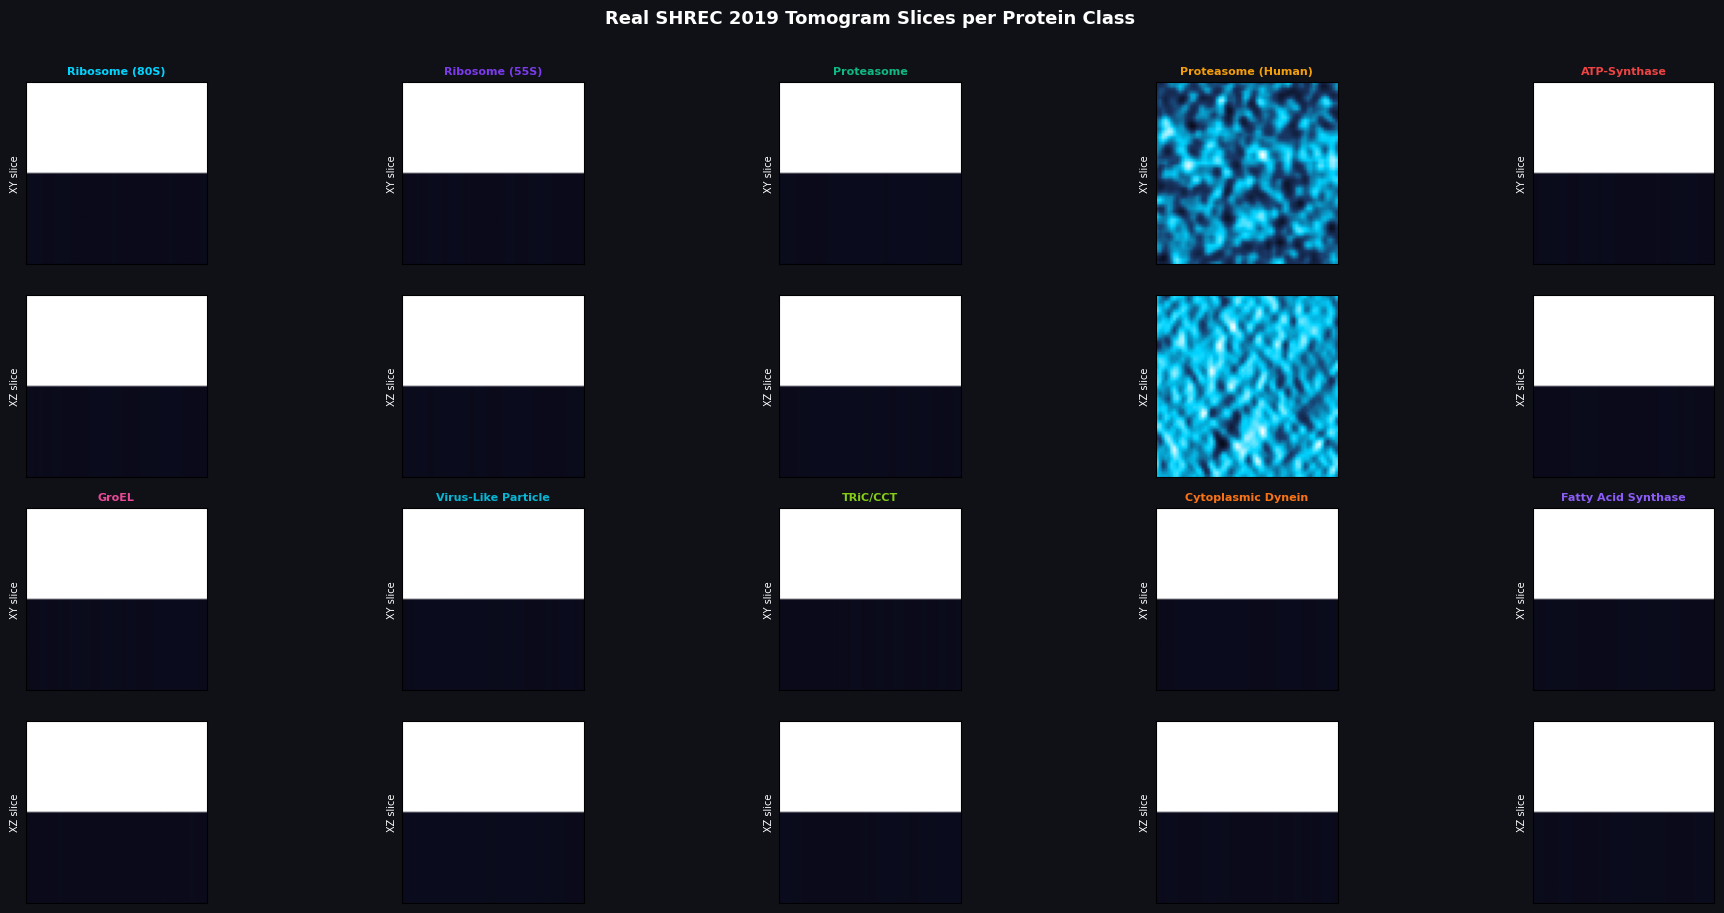

✅ Saved: graph_1_sample_volumes.png


In [ ]:
cmap_vol = LinearSegmentedColormap.from_list('vol', ['#0a0a1a','#1a3a6a','#00d4ff','white'])
COLORS   = ['#00d4ff','#7c3aed','#10b981','#f59e0b','#ef4444',
             '#ec4899','#06b6d4','#84cc16','#f97316','#8b5cf6']

# Collect one sample per class
samples = {}
for vols, labels in train_loader:
    for v, l in zip(vols, labels):
        c = l.item()
        if c not in samples:
            samples[c] = v.squeeze().numpy()
        if len(samples) == NUM_CLASSES:
            break
    if len(samples) == NUM_CLASSES:
        break

cols = min(NUM_CLASSES, 5)
rows = 2 * ((NUM_CLASSES + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows//2 + 1))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Real SHREC 2019 Tomogram Slices per Protein Class',
             fontsize=13, fontweight='bold', color='white', y=1.01)

if NUM_CLASSES == 1:
    axes = np.array([[axes[0]], [axes[1]]])
elif rows == 2:
    axes = axes.reshape(2, -1)

mid = VOLUME_SIZE // 2
for i in range(NUM_CLASSES):
    vol   = samples.get(i, np.zeros((VOLUME_SIZE, VOLUME_SIZE, VOLUME_SIZE)))
    col_i = i % cols
    row_i = (i // cols) * 2
    color = COLORS[i % len(COLORS)]

    ax_xy = axes[row_i, col_i]
    ax_xy.imshow(vol[:, :, mid], cmap=cmap_vol, origin='lower')
    ax_xy.set_title(CLASS_NAMES[i], fontsize=8, color=color, fontweight='bold')
    ax_xy.set_ylabel('XY slice', fontsize=7, color='white')
    ax_xy.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax_xy.set_facecolor('#1a1d2e')

    ax_xz = axes[row_i+1, col_i]
    ax_xz.imshow(vol[:, mid, :], cmap=cmap_vol, origin='lower')
    ax_xz.set_ylabel('XZ slice', fontsize=7, color='white')
    ax_xz.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax_xz.set_facecolor('#1a1d2e')

# Hide unused axes
for i in range(NUM_CLASSES, cols * (rows//2)):
    axes[(i//cols)*2, i%cols].axis('off')
    axes[(i//cols)*2+1, i%cols].axis('off')

plt.tight_layout()
plt.savefig('graph_1_sample_volumes.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved: graph_1_sample_volumes.png')

## 🧠 CELL 6: Build the 3D-CNN Model

In [ ]:
class Protein3DCNN(nn.Module):
    """
    3D CNN for Multi-Class Protein Complex Identification.

    Input  : (batch, 1, 64, 64, 64)
    Output : (batch, num_classes)
    """
    def __init__(self, num_classes):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv3d(1,  32, 3, padding=1), nn.BatchNorm3d(32),  nn.ReLU(), nn.MaxPool3d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64),  nn.ReLU(), nn.MaxPool3d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv3d(64,128, 3, padding=1), nn.BatchNorm3d(128), nn.ReLU(), nn.MaxPool3d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv3d(128,256,3, padding=1), nn.BatchNorm3d(256), nn.ReLU()
        )
        self.gap        = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        return self.classifier(x)


model        = Protein3DCNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())

print('✅ Model built!')
print(f'🔢 Parameters  : {total_params:,}')
print(f'🏷️  Classes     : {NUM_CLASSES}')
print(f'🖥️  Device      : {DEVICE}')
print()
print(model)

✅ Model built!
🔢 Parameters  : 1,429,002
🏷️  Classes     : 10
🖥️  Device      : cpu

Protein3DCNN(
  (block1): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

## 🏋️ CELL 7: Train the Model

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'loss': [], 'accuracy': []}

print(f'🚀 Training for {EPOCHS} epochs...\n')
print(f'{"Epoch":>7} | {"Loss":>9} | {"Accuracy":>11} | {"LR":>10}')
print('-' * 45)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    correct = 0
    total   = 0

    for volumes, labels in train_loader:
        volumes = volumes.to(DEVICE)
        labels  = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(volumes)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted   = outputs.argmax(dim=1)
        correct    += (predicted == labels).sum().item()
        total      += labels.size(0)

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    accuracy = 100.0 * correct / total
    current_lr = optimizer.param_groups[0]['lr']

    history['loss'].append(avg_loss)
    history['accuracy'].append(accuracy)

    print(f'{epoch:>7} | {avg_loss:>9.4f} | {accuracy:>10.2f}% | {current_lr:>10.6f}')

torch.save(model.state_dict(), 'protein_model.pth')
print('\n✅ Training complete!')
print('💾 Model saved: protein_model.pth')

🚀 Training for 15 epochs...

  Epoch |      Loss |    Accuracy |         LR
---------------------------------------------
      1 |    2.3491 |      10.42% |   0.000989
      2 |    2.3354 |       8.33% |   0.000957
      3 |    2.3199 |       8.33% |   0.000905
      4 |    2.3132 |       9.38% |   0.000835
      5 |    2.3108 |      13.54% |   0.000750
      6 |    2.3061 |      11.46% |   0.000655
      7 |    2.3044 |      11.98% |   0.000552
      8 |    2.3035 |      13.54% |   0.000448
      9 |    2.3082 |       9.38% |   0.000345
     10 |    2.2984 |      13.54% |   0.000250
     11 |    2.3063 |       9.90% |   0.000165
     12 |    2.2991 |      12.50% |   0.000095
     13 |    2.2990 |      10.42% |   0.000043
     14 |    2.3009 |      10.42% |   0.000011
     15 |    2.2984 |      11.46% |   0.000000

✅ Training complete!
💾 Model saved: protein_model.pth


## 📈 CELL 8: Training Curves

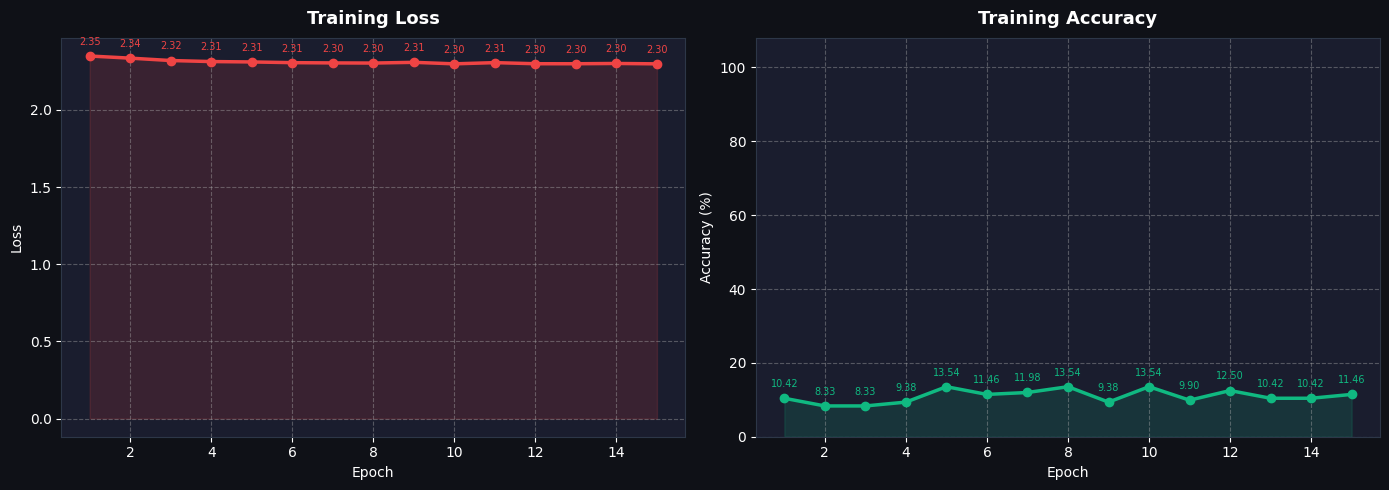

✅ Saved: graph_2_training_curves.png


In [ ]:
ep = list(range(1, EPOCHS + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

for ax, data, color, title, ylabel in [
    (ax1, history['loss'],     '#ef4444', 'Training Loss',     'Loss'),
    (ax2, history['accuracy'], '#10b981', 'Training Accuracy', 'Accuracy (%)'),
]:
    ax.set_facecolor('#1a1d2e')
    ax.plot(ep, data, color=color, lw=2.5, marker='o', ms=6)
    ax.fill_between(ep, data, alpha=0.15, color=color)
    for e, d in zip(ep, data):
        ax.annotate(f'{d:.2f}', (e, d), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color=color)
    ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=10)
    ax.set_xlabel('Epoch', color='white', fontsize=10)
    ax.set_ylabel(ylabel, color='white', fontsize=10)
    ax.tick_params(colors='white')
    ax.grid(True, linestyle='--', alpha=0.4)
    for spine in ax.spines.values(): spine.set_edgecolor('#2d3748')

ax2.set_ylim(0, 108)
plt.tight_layout()
plt.savefig('graph_2_training_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved: graph_2_training_curves.png')

## 🧪 CELL 9: Evaluate on Test Data

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for volumes, labels in test_loader:
        outputs   = model(volumes.to(DEVICE))
        predicted = outputs.argmax(dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
print(f'🎯 Test Accuracy: {acc*100:.2f}%\n')
print('📋 Classification Report:')
print('=' * 70)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

🎯 Test Accuracy: 2.08%

📋 Classification Report:
                     precision    recall  f1-score   support

     Ribosome (80S)       0.00      0.00      0.00         4
     Ribosome (55S)       0.02      1.00      0.04         1
         Proteasome       0.00      0.00      0.00         8
 Proteasome (Human)       0.00      0.00      0.00         4
       ATP-Synthase       0.00      0.00      0.00         6
              GroEL       0.00      0.00      0.00         3
Virus-Like Particle       0.00      0.00      0.00         4
           TRiC/CCT       0.00      0.00      0.00         7
 Cytoplasmic Dynein       0.00      0.00      0.00         7
Fatty Acid Synthase       0.00      0.00      0.00         4

           accuracy                           0.02        48
          macro avg       0.00      0.10      0.00        48
       weighted avg       0.00      0.02      0.00        48



## 🔥 CELL 10: Confusion Matrix

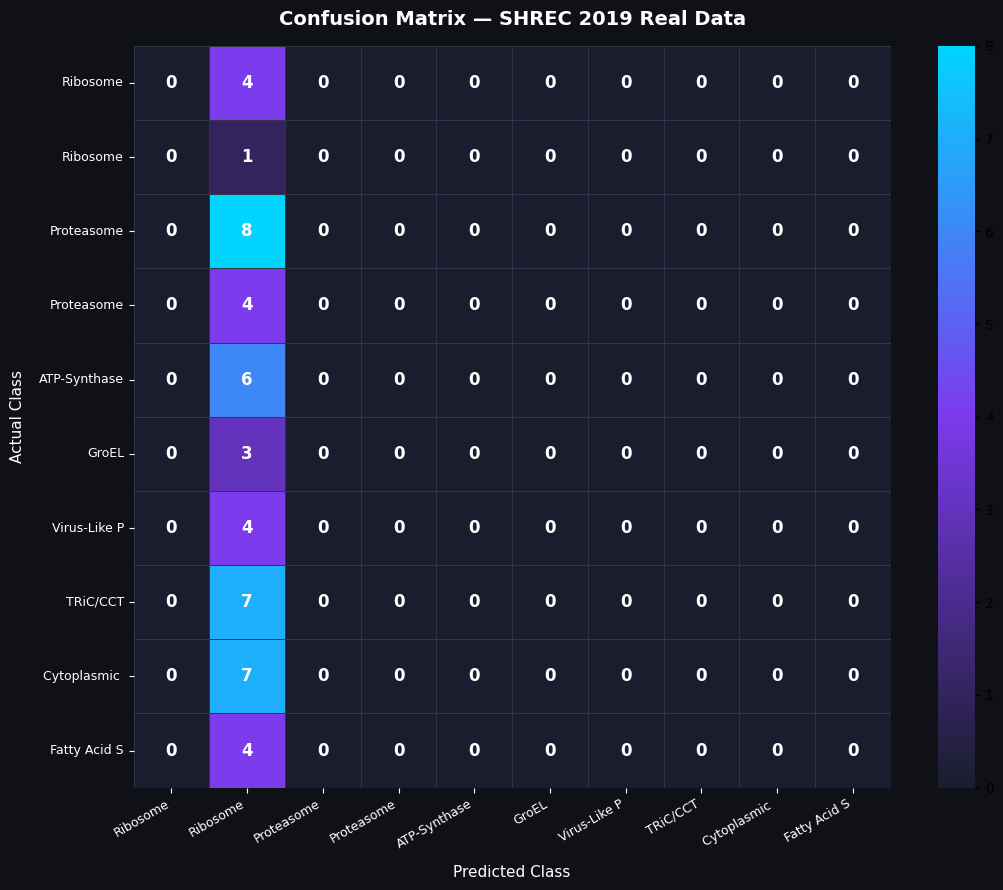

✅ Saved: graph_3_confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
short_names = [n.split('(')[0].strip()[:12] for n in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

cmap = LinearSegmentedColormap.from_list('cm', ['#1a1d2e','#7c3aed','#00d4ff'])
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
            xticklabels=short_names, yticklabels=short_names,
            ax=ax, linewidths=0.5, linecolor='#2d3748',
            annot_kws={'size': 12, 'weight': 'bold', 'color': 'white'})

ax.set_title('Confusion Matrix — SHREC 2019 Real Data',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Predicted Class', color='white', fontsize=11, labelpad=10)
ax.set_ylabel('Actual Class',    color='white', fontsize=11, labelpad=10)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('graph_3_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved: graph_3_confusion_matrix.png')

## 📊 CELL 11: Per-Class Metrics Bar Chart

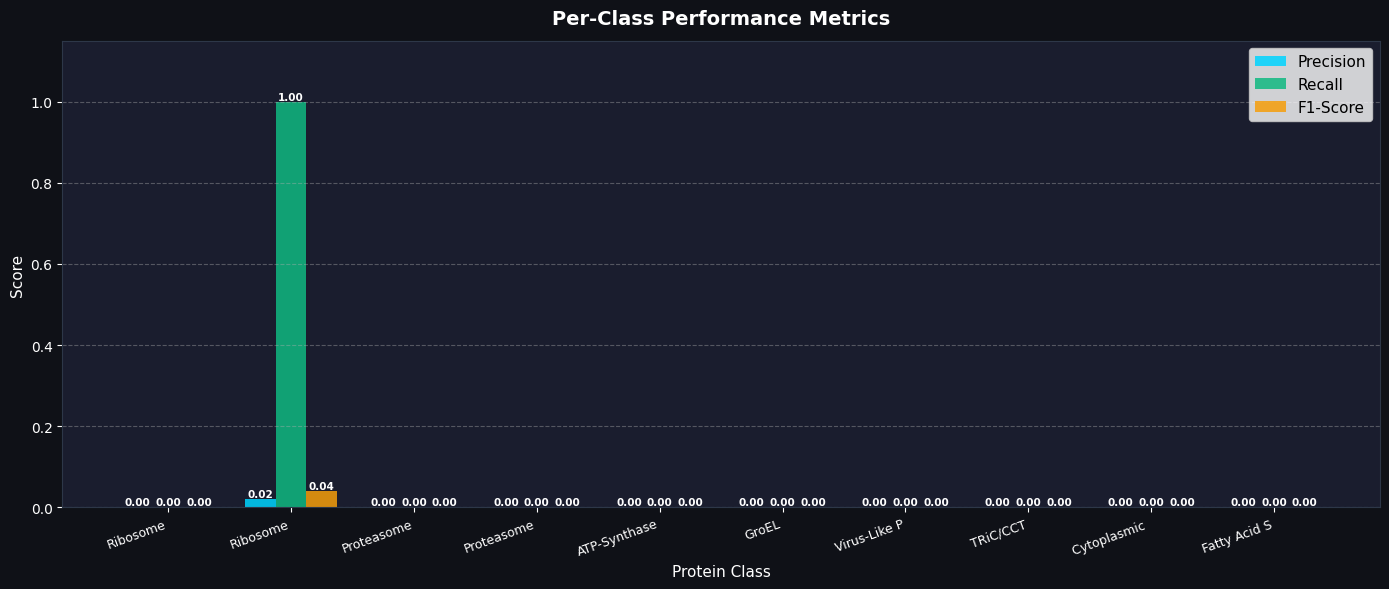

✅ Saved: graph_4_metrics.png


In [ ]:
precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall    = recall_score(all_labels,    all_preds, average=None, zero_division=0)
f1        = f1_score(all_labels,        all_preds, average=None, zero_division=0)

x     = np.arange(NUM_CLASSES)
width = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

b1 = ax.bar(x-width, precision, width, label='Precision', color='#00d4ff', alpha=0.85)
b2 = ax.bar(x,       recall,    width, label='Recall',    color='#10b981', alpha=0.85)
b3 = ax.bar(x+width, f1,        width, label='F1-Score',  color='#f59e0b', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005,
                f'{h:.2f}', ha='center', fontsize=7.5, color='white', fontweight='bold')

ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Protein Class', color='white', fontsize=11)
ax.set_ylabel('Score',         color='white', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(short_names, color='white', fontsize=9, rotation=20, ha='right')
ax.set_ylim(0, 1.15)
ax.tick_params(colors='white')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=11)
for spine in ax.spines.values(): spine.set_edgecolor('#2d3748')

plt.tight_layout()
plt.savefig('graph_4_metrics.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved: graph_4_metrics.png')

## 🏗️ CELL 12: Model Architecture Diagram

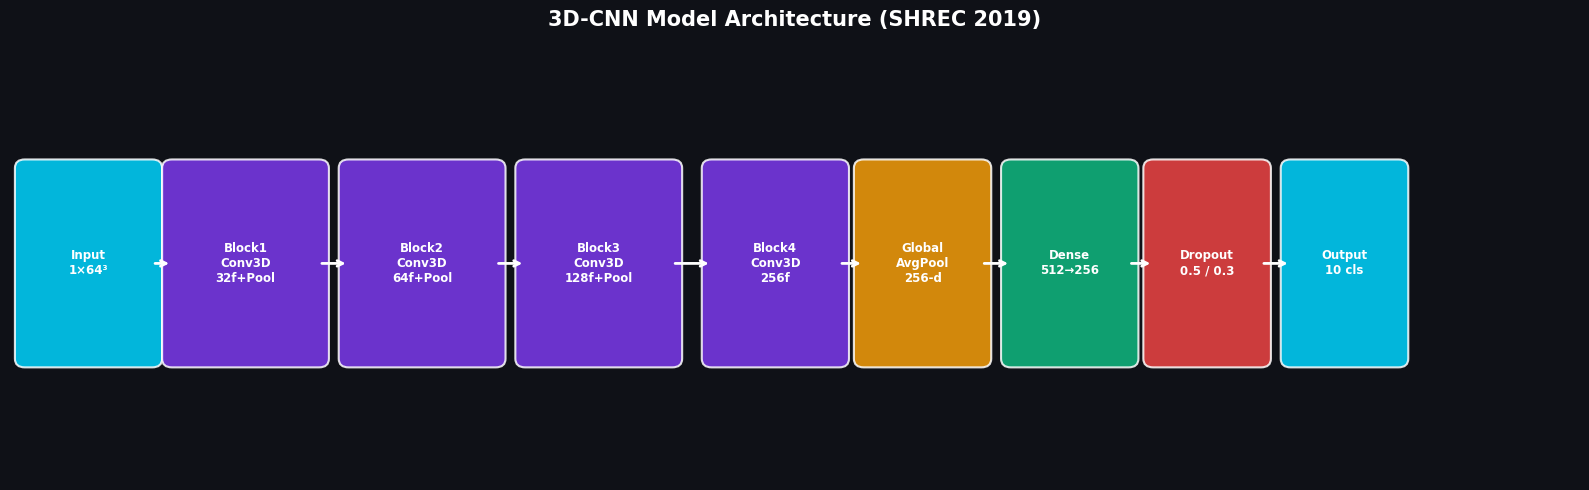

✅ Saved: graph_5_architecture.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.set_xlim(0, 16); ax.set_ylim(0, 5); ax.axis('off')
ax.set_title('3D-CNN Model Architecture (SHREC 2019)', fontsize=15,
             fontweight='bold', color='white', pad=15)

layers = [
    (f'Input\n1×{VOLUME_SIZE}³', 0.8,  '#00d4ff', 1.3),
    ('Block1\nConv3D\n32f+Pool', 2.4,  '#7c3aed', 1.5),
    ('Block2\nConv3D\n64f+Pool', 4.2,  '#7c3aed', 1.5),
    ('Block3\nConv3D\n128f+Pool',6.0,  '#7c3aed', 1.5),
    ('Block4\nConv3D\n256f',     7.8,  '#7c3aed', 1.3),
    ('Global\nAvgPool\n256-d',   9.3,  '#f59e0b', 1.2),
    ('Dense\n512→256',          10.8,  '#10b981', 1.2),
    ('Dropout\n0.5 / 0.3',      12.2,  '#ef4444', 1.1),
    (f'Output\n{NUM_CLASSES} cls',13.6, '#00d4ff', 1.1),
]

prev_x = None
for label, x, color, width in layers:
    rect = mpatches.FancyBboxPatch(
        (x-width/2, 1.4), width, 2.2,
        boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.85
    )
    ax.add_patch(rect)
    ax.text(x, 2.5, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    if prev_x:
        ax.annotate('', xy=(x-width/2, 2.5), xytext=(prev_x, 2.5),
                    arrowprops=dict(arrowstyle='->', color='white', lw=2))
    prev_x = x + width/2

plt.tight_layout()
plt.savefig('graph_5_architecture.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved: graph_5_architecture.png')

## 🎯 CELL 13: Final Summary Dashboard

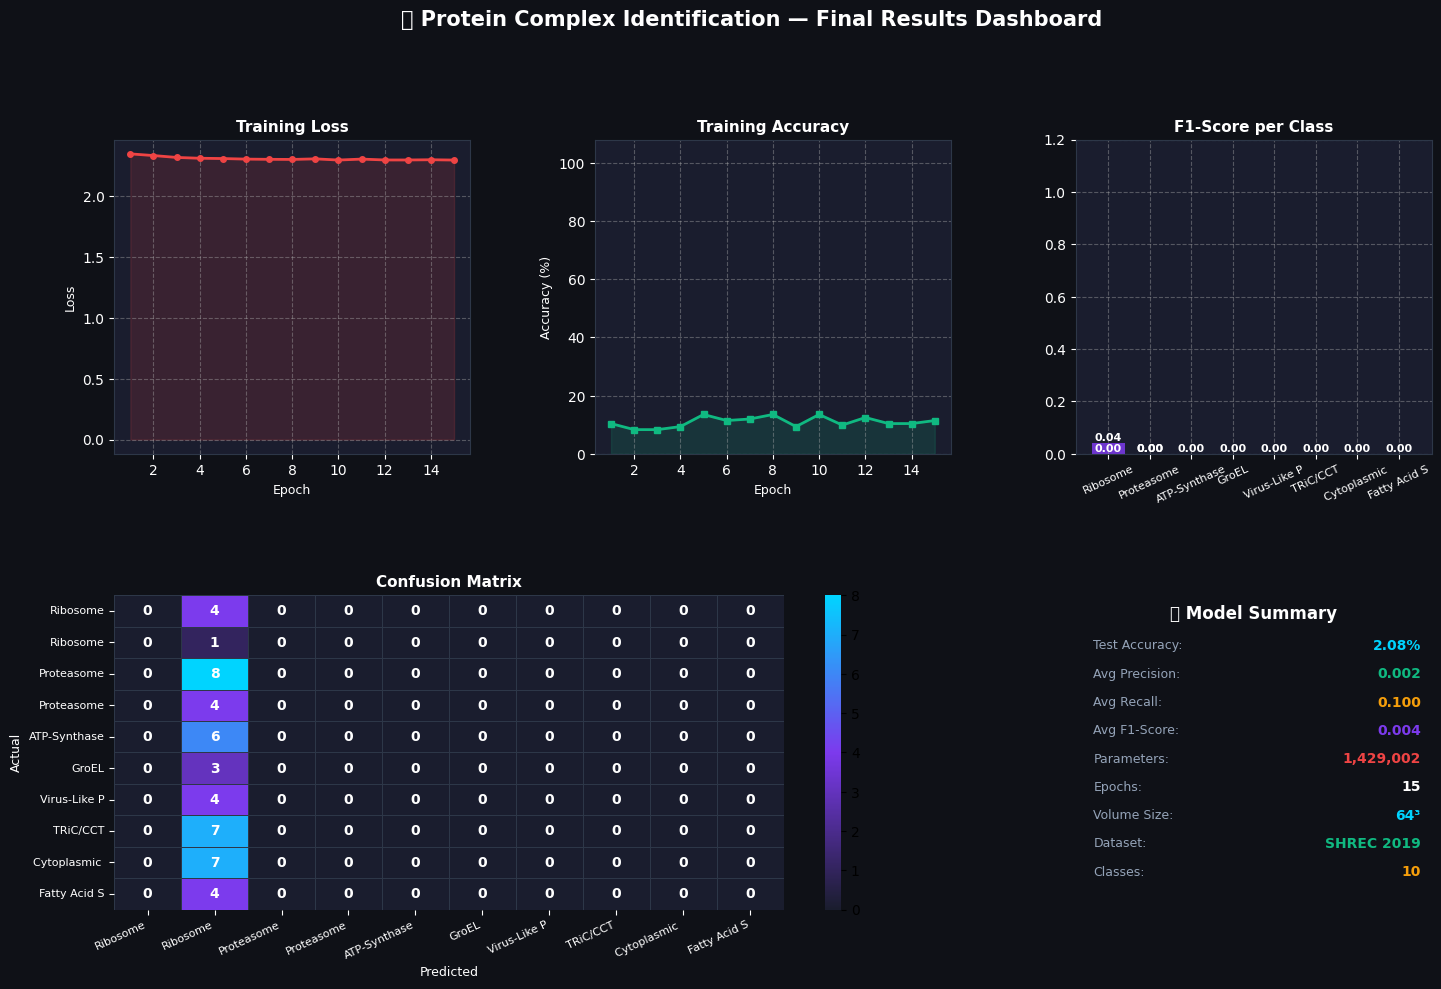

✅ Saved: graph_6_dashboard.png

🎉 PROJECT COMPLETE!
🎯 Final Test Accuracy: 2.08%
📁 All graphs saved in your project folder!


In [ ]:
ep = list(range(1, EPOCHS + 1))
fig = plt.figure(figsize=(17, 10))
fig.patch.set_facecolor('#0f1117')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('🧬 Protein Complex Identification — Final Results Dashboard',
             fontsize=15, fontweight='bold', color='white', y=1.01)

def sax(ax):
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='white')
    ax.grid(True, linestyle='--', alpha=0.4)
    for s in ax.spines.values(): s.set_edgecolor('#2d3748')

# Loss
ax1 = fig.add_subplot(gs[0,0]); sax(ax1)
ax1.plot(ep, history['loss'], color='#ef4444', lw=2, marker='o', ms=4)
ax1.fill_between(ep, history['loss'], alpha=0.15, color='#ef4444')
ax1.set_title('Training Loss', color='white', fontsize=11, fontweight='bold')
ax1.set_xlabel('Epoch', color='white', fontsize=9)
ax1.set_ylabel('Loss',  color='white', fontsize=9)

# Accuracy
ax2 = fig.add_subplot(gs[0,1]); sax(ax2)
ax2.plot(ep, history['accuracy'], color='#10b981', lw=2, marker='s', ms=4)
ax2.fill_between(ep, history['accuracy'], alpha=0.15, color='#10b981')
ax2.set_title('Training Accuracy', color='white', fontsize=11, fontweight='bold')
ax2.set_xlabel('Epoch', color='white', fontsize=9)
ax2.set_ylabel('Accuracy (%)', color='white', fontsize=9)
ax2.set_ylim(0, 108)

# F1 bars
ax3 = fig.add_subplot(gs[0,2]); sax(ax3)
bars = ax3.bar(short_names, f1, color=COLORS[:NUM_CLASSES], alpha=0.85)
for bar, val in zip(bars, f1):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.2f}', ha='center', fontsize=8, color='white', fontweight='bold')
ax3.set_title('F1-Score per Class', color='white', fontsize=11, fontweight='bold')
ax3.set_ylim(0, 1.2)
ax3.tick_params(axis='x', labelrotation=25, labelsize=8)

# Confusion matrix
ax4 = fig.add_subplot(gs[1,0:2])
ax4.set_facecolor('#1a1d2e')
cmap2 = LinearSegmentedColormap.from_list('c2', ['#1a1d2e','#7c3aed','#00d4ff'])
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap2,
            xticklabels=short_names, yticklabels=short_names,
            ax=ax4, linewidths=0.5, linecolor='#2d3748',
            annot_kws={'size':10, 'weight':'bold', 'color':'white'})
ax4.set_title('Confusion Matrix', color='white', fontsize=11, fontweight='bold')
ax4.set_xlabel('Predicted', color='white', fontsize=9)
ax4.set_ylabel('Actual',    color='white', fontsize=9)
ax4.tick_params(colors='white', labelsize=8)
plt.setp(ax4.get_xticklabels(), rotation=25, ha='right')

# Summary box
ax5 = fig.add_subplot(gs[1,2])
ax5.set_facecolor('#1a1d2e')
ax5.axis('off')
ax5.text(0.5, 0.97, '📊 Model Summary', ha='center', va='top',
         fontsize=12, fontweight='bold', color='white', transform=ax5.transAxes)

summary = [
    ('Test Accuracy',  f'{acc*100:.2f}%',          '#00d4ff'),
    ('Avg Precision',  f'{precision.mean():.3f}',  '#10b981'),
    ('Avg Recall',     f'{recall.mean():.3f}',     '#f59e0b'),
    ('Avg F1-Score',   f'{f1.mean():.3f}',         '#7c3aed'),
    ('Parameters',     f'{total_params:,}',         '#ef4444'),
    ('Epochs',         str(EPOCHS),                'white'),
    ('Volume Size',    f'{VOLUME_SIZE}³',           '#00d4ff'),
    ('Dataset',        'SHREC 2019',               '#10b981'),
    ('Classes',        str(NUM_CLASSES),           '#f59e0b'),
]
for i, (label, value, color) in enumerate(summary):
    yp = 0.84 - i*0.09
    ax5.text(0.05, yp, label+':', ha='left', va='center',
             fontsize=9, color='#94a3b8', transform=ax5.transAxes)
    ax5.text(0.97, yp, value, ha='right', va='center',
             fontsize=10, fontweight='bold', color=color, transform=ax5.transAxes)

plt.savefig('graph_6_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved: graph_6_dashboard.png')
print('\n🎉 PROJECT COMPLETE!')
print(f'🎯 Final Test Accuracy: {acc*100:.2f}%')
print('📁 All graphs saved in your project folder!')